In [4]:
from pathlib import Path
from collections import Counter

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from skimage.feature import (
    local_binary_pattern,
    graycomatrix,
    graycoprops
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Librerías importadas correctamente")


Librerías importadas correctamente


In [5]:
CARPETA_PROYECTO = Path(
    r"C:\MachinL\ProyectoFinal"
)

RUTA_DATASET = (
    CARPETA_PROYECTO
    / "Clean_dataset_segmented_yolo"
)

RUTA_MODELOS = (
    CARPETA_PROYECTO
    / "modelos_ml"
)

RUTA_RESULTADOS = (
    CARPETA_PROYECTO
    / "resultados_ml"
)

RUTA_MODELOS.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_RESULTADOS.mkdir(
    parents=True,
    exist_ok=True
)

print("Proyecto:", CARPETA_PROYECTO)
print("Dataset:", RUTA_DATASET)
print("Dataset existe:", RUTA_DATASET.exists())
print("Modelos:", RUTA_MODELOS)
print("Resultados:", RUTA_RESULTADOS)

Proyecto: C:\MachinL\ProyectoFinal
Dataset: C:\MachinL\ProyectoFinal\Clean_dataset_segmented_yolo
Dataset existe: True
Modelos: C:\MachinL\ProyectoFinal\modelos_ml
Resultados: C:\MachinL\ProyectoFinal\resultados_ml


In [7]:
RUTA_TRAIN = RUTA_DATASET / "Train"

CLASES = sorted([
    carpeta.name
    for carpeta in RUTA_TRAIN.iterdir()
    if carpeta.is_dir()
])

print("Clases encontradas:")
print(CLASES)

print("\nNúmero de clases:")
print(len(CLASES))

Clases encontradas:
['Blackspot', 'Canker', 'HLB', 'Healthy', 'Melanosis']

Número de clases:
5


In [8]:
EXTENSIONES_VALIDAS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


def obtener_imagenes(carpeta):
    return [
        archivo
        for archivo in carpeta.rglob("*")
        if (
            archivo.is_file()
            and archivo.suffix.lower()
            in EXTENSIONES_VALIDAS
        )
    ]


registros_conteo = []

for division in DIVISIONES:
    for clase in CLASES:

        carpeta_clase = (
            RUTA_DATASET
            / division
            / clase
        )

        imagenes = obtener_imagenes(
            carpeta_clase
        )

        registros_conteo.append({
            "division": division,
            "clase": clase,
            "cantidad": len(imagenes)
        })


df_conteo = pd.DataFrame(
    registros_conteo
)

tabla_conteo = df_conteo.pivot(
    index="clase",
    columns="division",
    values="cantidad"
).fillna(0).astype(int)

tabla_conteo

division,Test,Train,Val
clase,,,
Blackspot,145,514,288
Canker,200,505,399
HLB,37,258,74
Healthy,200,318,398
Melanosis,200,251,400


In [9]:
print("Totales por división:")

for division in DIVISIONES:
    total = df_conteo.loc[
        df_conteo["division"] == division,
        "cantidad"
    ].sum()

    print(
        f"{division}: {total}"
    )

Totales por división:
Train: 1846
Val: 1559
Test: 782


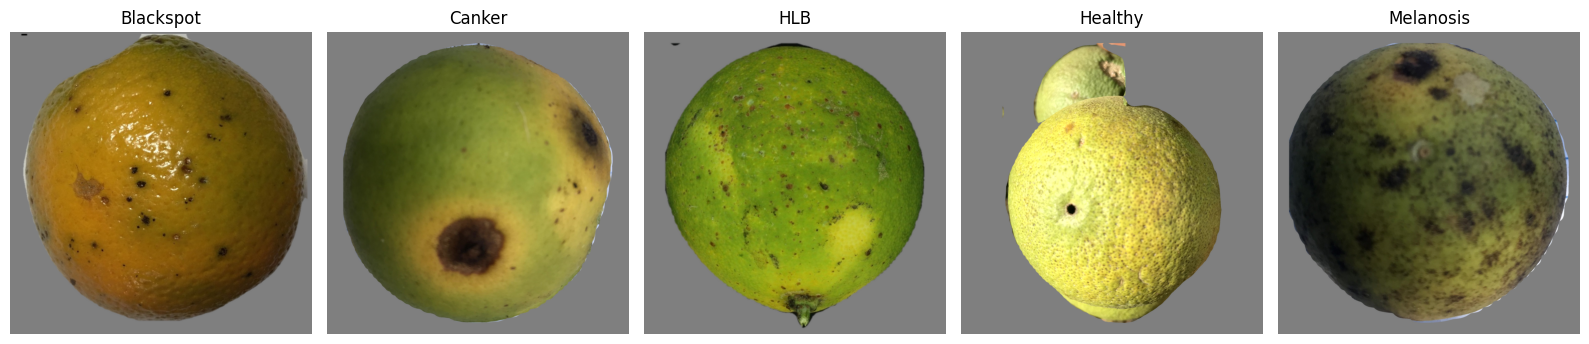

In [10]:
def mostrar_ejemplos(
    ruta_dataset,
    clases,
    division="Train"
):
    figura, ejes = plt.subplots(
        1,
        len(clases),
        figsize=(16, 4)
    )

    for eje, clase in zip(
        ejes,
        clases
    ):
        carpeta = (
            ruta_dataset
            / division
            / clase
        )

        imagenes = obtener_imagenes(
            carpeta
        )

        if len(imagenes) == 0:
            eje.set_title(
                f"{clase}\nSin imágenes"
            )
            eje.axis("off")
            continue

        ruta_imagen = imagenes[0]

        imagen_bgr = cv2.imread(
            str(ruta_imagen)
        )

        imagen_rgb = cv2.cvtColor(
            imagen_bgr,
            cv2.COLOR_BGR2RGB
        )

        eje.imshow(imagen_rgb)
        eje.set_title(clase)
        eje.axis("off")

    plt.tight_layout()
    plt.show()


mostrar_ejemplos(
    RUTA_DATASET,
    CLASES,
    division="Train"
)

In [13]:
FONDO_GRIS = 127
UMBRAL_FONDO = 15


def crear_mascara_fruto(imagen_rgb):
    """
    Crea una máscara binaria:
    1 = fruto
    0 = fondo gris
    """

    imagen_float = imagen_rgb.astype(
        np.float32
    )

    fondo = np.array(
        [FONDO_GRIS, FONDO_GRIS, FONDO_GRIS],
        dtype=np.float32
    )

    diferencia = np.linalg.norm(
        imagen_float - fondo,
        axis=2
    )

    mascara = (
        diferencia > UMBRAL_FONDO
    ).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    mascara = cv2.morphologyEx(
        mascara,
        cv2.MORPH_OPEN,
        kernel
    )

    mascara = cv2.morphologyEx(
        mascara,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Conservar solamente el componente principal
    numero_componentes, etiquetas, estadisticas, _ = (
        cv2.connectedComponentsWithStats(
            mascara,
            connectivity=8
        )
    )

    if numero_componentes <= 1:
        return mascara

    areas = estadisticas[
        1:,
        cv2.CC_STAT_AREA
    ]

    componente_mayor = (
        1 + int(np.argmax(areas))
    )

    mascara_principal = (
        etiquetas == componente_mayor
    ).astype(np.uint8) * 255

    return mascara_principal

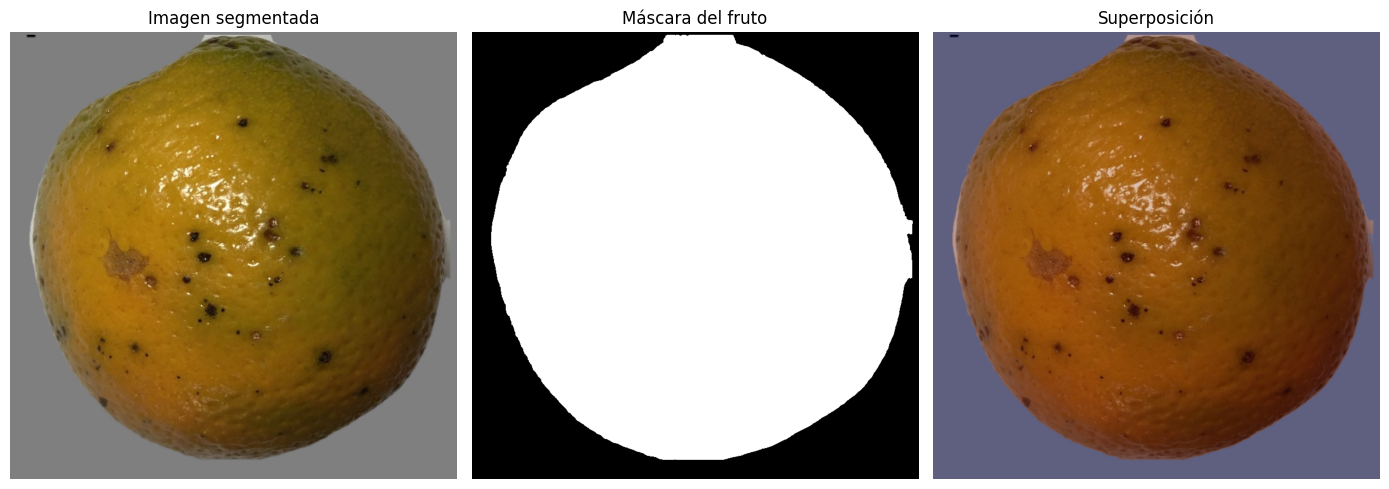

Imagen: Blackspot_0003202d.png
Porcentaje de fruto: 67.78%


In [14]:
ruta_ejemplo = obtener_imagenes(
    RUTA_DATASET / "Train" / CLASES[0]
)[0]

imagen_bgr = cv2.imread(
    str(ruta_ejemplo)
)

if imagen_bgr is None:
    raise ValueError(
        f"No se pudo leer: {ruta_ejemplo}"
    )

imagen_rgb = cv2.cvtColor(
    imagen_bgr,
    cv2.COLOR_BGR2RGB
)

mascara = crear_mascara_fruto(
    imagen_rgb
)

figura, ejes = plt.subplots(
    1,
    3,
    figsize=(14, 5)
)

ejes[0].imshow(imagen_rgb)
ejes[0].set_title("Imagen segmentada")
ejes[0].axis("off")

ejes[1].imshow(
    mascara,
    cmap="gray"
)
ejes[1].set_title("Máscara del fruto")
ejes[1].axis("off")

ejes[2].imshow(imagen_rgb)
ejes[2].imshow(
    mascara,
    cmap="jet",
    alpha=0.25
)
ejes[2].set_title("Superposición")
ejes[2].axis("off")

plt.tight_layout()
plt.show()

print("Imagen:", ruta_ejemplo.name)
print(
    "Porcentaje de fruto:",
    f"{(mascara > 0).mean() * 100:.2f}%"
)

In [15]:
def estadisticas_canal(
    imagen,
    mascara_bool,
    prefijos
):
    caracteristicas = {}

    for indice, nombre in enumerate(prefijos):
        valores = imagen[
            :, :,
            indice
        ][mascara_bool]

        if valores.size == 0:
            media = 0.0
            desviacion = 0.0
            mediana = 0.0
        else:
            media = float(np.mean(valores))
            desviacion = float(np.std(valores))
            mediana = float(np.median(valores))

        caracteristicas[
            f"{nombre}_media"
        ] = media

        caracteristicas[
            f"{nombre}_std"
        ] = desviacion

        caracteristicas[
            f"{nombre}_mediana"
        ] = mediana

    return caracteristicas

In [24]:
def extraer_estadisticas_color(
    imagen_rgb,
    mascara
):
    mascara_bool = mascara > 0

    imagen_hsv = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2HSV
    )

    imagen_lab = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2LAB
    )

    caracteristicas = {}

    caracteristicas.update(
        estadisticas_canal(
            imagen_rgb,
            mascara_bool,
            ["R", "G", "B"]
        )
    )

    caracteristicas.update(
        estadisticas_canal(
            imagen_hsv,
            mascara_bool,
            ["H", "S", "V"]
        )
    )

    caracteristicas.update(
        estadisticas_canal(
            imagen_lab,
            mascara_bool,
            ["L", "A", "LAB_B"]
        )
    )

    return caracteristicas

In [16]:
def histograma_normalizado(
    canal,
    mascara,
    numero_bins,
    rango
):
    histograma = cv2.calcHist(
        [canal],
        [0],
        mascara,
        [numero_bins],
        rango
    )

    histograma = histograma.flatten()

    suma = histograma.sum()

    if suma > 0:
        histograma = histograma / suma

    return histograma

In [17]:
def extraer_histogramas_hsv(
    imagen_rgb,
    mascara,
    bins_h=18,
    bins_s=16,
    bins_v=16
):
    imagen_hsv = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2HSV
    )

    h, s, v = cv2.split(
        imagen_hsv
    )

    hist_h = histograma_normalizado(
        h,
        mascara,
        bins_h,
        [0, 180]
    )

    hist_s = histograma_normalizado(
        s,
        mascara,
        bins_s,
        [0, 256]
    )

    hist_v = histograma_normalizado(
        v,
        mascara,
        bins_v,
        [0, 256]
    )

    caracteristicas = {}

    for indice, valor in enumerate(hist_h):
        caracteristicas[
            f"hist_h_{indice:02d}"
        ] = float(valor)

    for indice, valor in enumerate(hist_s):
        caracteristicas[
            f"hist_s_{indice:02d}"
        ] = float(valor)

    for indice, valor in enumerate(hist_v):
        caracteristicas[
            f"hist_v_{indice:02d}"
        ] = float(valor)

    return caracteristicas

In [18]:
LBP_RADIO = 2
LBP_PUNTOS = 8 * LBP_RADIO
LBP_METODO = "uniform"

In [19]:
def extraer_lbp(
    imagen_rgb,
    mascara
):
    gris = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2GRAY
    )

    lbp = local_binary_pattern(
        gris,
        P=LBP_PUNTOS,
        R=LBP_RADIO,
        method=LBP_METODO
    )

    mascara_bool = mascara > 0

    valores_lbp = lbp[
        mascara_bool
    ]

    numero_bins = (
        LBP_PUNTOS + 2
    )

    histograma, _ = np.histogram(
        valores_lbp,
        bins=np.arange(
            0,
            numero_bins + 1
        ),
        range=(0, numero_bins)
    )

    histograma = histograma.astype(
        np.float32
    )

    if histograma.sum() > 0:
        histograma /= histograma.sum()

    return {
        f"lbp_{indice:02d}": float(valor)
        for indice, valor
        in enumerate(histograma)
    }

In [20]:
def extraer_glcm(
    imagen_rgb,
    mascara
):
    gris = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2GRAY
    )

    puntos = cv2.findNonZero(
        mascara
    )

    if puntos is None:
        return {
            "glcm_contraste": 0.0,
            "glcm_disimilitud": 0.0,
            "glcm_homogeneidad": 0.0,
            "glcm_energia": 0.0,
            "glcm_correlacion": 0.0,
            "glcm_ASM": 0.0
        }

    x, y, ancho, alto = cv2.boundingRect(
        puntos
    )

    recorte_gris = gris[
        y:y + alto,
        x:x + ancho
    ].copy()

    recorte_mascara = mascara[
        y:y + alto,
        x:x + ancho
    ] > 0

    valores_fruto = recorte_gris[
        recorte_mascara
    ]

    if valores_fruto.size == 0:
        valor_relleno = 127
    else:
        valor_relleno = int(
            np.median(valores_fruto)
        )

    recorte_gris[
        ~recorte_mascara
    ] = valor_relleno

    recorte_gris = cv2.resize(
        recorte_gris,
        (128, 128),
        interpolation=cv2.INTER_AREA
    )

    # Reducir de 256 a 16 niveles de gris
    imagen_cuantizada = (
        recorte_gris // 16
    ).astype(np.uint8)

    matriz_glcm = graycomatrix(
        imagen_cuantizada,
        distances=[1, 2],
        angles=[
            0,
            np.pi / 4,
            np.pi / 2,
            3 * np.pi / 4
        ],
        levels=16,
        symmetric=True,
        normed=True
    )

    propiedades = {
        "contraste": "contrast",
        "disimilitud": "dissimilarity",
        "homogeneidad": "homogeneity",
        "energia": "energy",
        "correlacion": "correlation",
        "ASM": "ASM"
    }

    caracteristicas = {}

    for nombre, propiedad in propiedades.items():
        valores = graycoprops(
            matriz_glcm,
            propiedad
        )

        caracteristicas[
            f"glcm_{nombre}"
        ] = float(
            np.mean(valores)
        )

    return caracteristicas

In [21]:
def extraer_proporciones_color(
    imagen_rgb,
    mascara
):
    hsv = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2HSV
    )

    h, s, v = cv2.split(
        hsv
    )

    fruto = mascara > 0

    total = int(
        np.sum(fruto)
    )

    if total == 0:
        return {
            "proporcion_oscura": 0.0,
            "proporcion_amarilla": 0.0,
            "proporcion_verde": 0.0,
            "proporcion_marron": 0.0,
            "proporcion_baja_saturacion": 0.0
        }

    oscura = (
        fruto
        & (v < 80)
    )

    amarilla = (
        fruto
        & (h >= 18)
        & (h <= 38)
        & (s > 60)
        & (v > 80)
    )

    verde = (
        fruto
        & (h >= 35)
        & (h <= 90)
        & (s > 40)
    )

    marron = (
        fruto
        & (
            (h <= 18)
            | (h >= 170)
        )
        & (s > 40)
        & (v >= 40)
        & (v <= 180)
    )

    baja_saturacion = (
        fruto
        & (s < 45)
    )

    return {
        "proporcion_oscura": float(
            np.sum(oscura) / total
        ),
        "proporcion_amarilla": float(
            np.sum(amarilla) / total
        ),
        "proporcion_verde": float(
            np.sum(verde) / total
        ),
        "proporcion_marron": float(
            np.sum(marron) / total
        ),
        "proporcion_baja_saturacion": float(
            np.sum(baja_saturacion) / total
        )
    }

In [22]:
def extraer_caracteristicas(
    ruta_imagen
):
    imagen_bgr = cv2.imread(
        str(ruta_imagen)
    )

    if imagen_bgr is None:
        raise ValueError(
            f"No se pudo leer: {ruta_imagen}"
        )

    imagen_rgb = cv2.cvtColor(
        imagen_bgr,
        cv2.COLOR_BGR2RGB
    )

    mascara = crear_mascara_fruto(
        imagen_rgb
    )

    cantidad_pixeles = int(
        np.sum(mascara > 0)
    )

    if cantidad_pixeles < 100:
        raise ValueError(
            "La máscara contiene muy pocos "
            f"píxeles: {cantidad_pixeles}"
        )

    caracteristicas = {}

    caracteristicas.update(
        extraer_estadisticas_color(
            imagen_rgb,
            mascara
        )
    )

    caracteristicas.update(
        extraer_histogramas_hsv(
            imagen_rgb,
            mascara
        )
    )

    caracteristicas.update(
        extraer_lbp(
            imagen_rgb,
            mascara
        )
    )

    caracteristicas.update(
        extraer_glcm(
            imagen_rgb,
            mascara
        )
    )

    caracteristicas.update(
        extraer_proporciones_color(
            imagen_rgb,
            mascara
        )
    )

    caracteristicas[
        "area_relativa_fruto"
    ] = float(
        np.mean(mascara > 0)
    )

    return caracteristicas

In [25]:
caracteristicas_ejemplo = (
    extraer_caracteristicas(
        ruta_ejemplo
    )
)

print(
    "Cantidad de características:",
    len(caracteristicas_ejemplo)
)

for nombre, valor in list(
    caracteristicas_ejemplo.items()
)[:20]:
    print(
        f"{nombre:30s}: {valor:.6f}"
    )

Cantidad de características: 107
R_media                       : 124.294853
R_std                         : 36.623534
R_mediana                     : 125.000000
G_media                       : 92.635469
G_std                         : 28.740258
G_mediana                     : 93.000000
B_media                       : 23.345474
B_std                         : 25.018749
B_mediana                     : 14.000000
H_media                       : 20.579443
H_std                         : 2.545882
H_mediana                     : 21.000000
S_media                       : 207.078626
S_std                         : 44.808286
S_mediana                     : 225.000000
V_media                       : 124.296145
V_std                         : 36.625805
V_mediana                     : 125.000000
L_media                       : 105.173963
L_std                         : 31.134391


In [26]:
valores = np.array(
    list(
        caracteristicas_ejemplo.values()
    ),
    dtype=float
)

print(
    "Valores NaN:",
    np.isnan(valores).sum()
)

print(
    "Valores infinitos:",
    np.isinf(valores).sum()
)

Valores NaN: 0
Valores infinitos: 0


In [27]:
def procesar_division(
    ruta_dataset,
    division,
    clases
):
    registros = []
    errores = []

    for clase in clases:
        carpeta_clase = (
            ruta_dataset
            / division
            / clase
        )

        imagenes = obtener_imagenes(
            carpeta_clase
        )

        descripcion = (
            f"{division} - {clase}"
        )

        for ruta_imagen in tqdm(
            imagenes,
            desc=descripcion
        ):
            try:
                caracteristicas = (
                    extraer_caracteristicas(
                        ruta_imagen
                    )
                )

                registro = {
                    "division": division,
                    "clase": clase,
                    "archivo": ruta_imagen.name,
                    "ruta": str(ruta_imagen)
                }

                registro.update(
                    caracteristicas
                )

                registros.append(
                    registro
                )

            except Exception as error:
                errores.append({
                    "division": division,
                    "clase": clase,
                    "archivo": ruta_imagen.name,
                    "ruta": str(ruta_imagen),
                    "error": str(error)
                })

    dataframe = pd.DataFrame(
        registros
    )

    dataframe_errores = pd.DataFrame(
        errores
    )

    return dataframe, dataframe_errores

In [28]:
df_train, errores_train = (
    procesar_division(
        RUTA_DATASET,
        division="Train",
        clases=CLASES
    )
)

print(
    "Imágenes procesadas:",
    len(df_train)
)

print(
    "Errores:",
    len(errores_train)
)

display(
    df_train.head()
)

Train - Blackspot:   0%|          | 0/514 [00:00<?, ?it/s]

Train - Canker:   0%|          | 0/505 [00:00<?, ?it/s]

Train - HLB:   0%|          | 0/258 [00:00<?, ?it/s]

Train - Healthy:   0%|          | 0/318 [00:00<?, ?it/s]

Train - Melanosis:   0%|          | 0/251 [00:00<?, ?it/s]

Imágenes procesadas: 1846
Errores: 0


,division,clase,archivo,ruta,R_media,R_std,R_mediana,G_media,G_std,G_mediana,...,glcm_homogeneidad,glcm_energia,glcm_correlacion,glcm_ASM,proporcion_oscura,proporcion_amarilla,proporcion_verde,proporcion_marron,proporcion_baja_saturacion,area_relativa_fruto
0,Train,Blackspot,Blackspot_0003202d.png,C:\MachinL\ProyectoFinal\Clean_dataset_segment...,124.294853,36.623534,125.0,92.635469,28.740258,93.0,...,0.863558,0.385919,0.892628,0.149028,0.118421,0.787164,0.0,0.182593,0.011644,0.677845
1,Train,Blackspot,Blackspot_00585398.png,C:\MachinL\ProyectoFinal\Clean_dataset_segment...,138.101040,31.230855,141.0,92.646725,26.403112,94.0,...,0.879121,0.482169,0.896269,0.232569,0.050157,0.594944,0.0,0.628095,0.012220,0.652881
2,Train,Blackspot,Blackspot_00964e23.png,C:\MachinL\ProyectoFinal\Clean_dataset_segment...,151.699670,33.900734,155.0,95.044202,25.643869,96.0,...,0.879566,0.442157,0.900417,0.195579,0.025224,0.150443,0.0,0.791465,0.009110,0.656143
3,Train,Blackspot,Blackspot_00e21a1c.png,C:\MachinL\ProyectoFinal\Clean_dataset_segment...,137.160700,33.848363,142.0,95.712268,27.690542,99.0,...,0.887340,0.431664,0.915030,0.186429,0.073357,0.767075,0.0,0.436684,0.012109,0.700278
4,Train,Blackspot,Blackspot_011acd0a.png,C:\MachinL\ProyectoFinal\Clean_dataset_segment...,124.755784,25.420608,128.0,93.293375,23.521624,95.0,...,0.869030,0.487423,0.829463,0.237700,0.058030,0.840825,0.0,0.197484,0.012325,0.658984


In [29]:
RUTA_CSV_TRAIN = (
    RUTA_RESULTADOS
    / "caracteristicas_train.csv"
)

df_train.to_csv(
    RUTA_CSV_TRAIN,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Guardado en:",
    RUTA_CSV_TRAIN
)

Guardado en: C:\MachinL\ProyectoFinal\resultados_ml\caracteristicas_train.csv


In [30]:
df_val, errores_val = (
    procesar_division(
        RUTA_DATASET,
        division="Val",
        clases=CLASES
    )
)

print(
    "Imágenes procesadas:",
    len(df_val)
)

print(
    "Errores:",
    len(errores_val)
)

Val - Blackspot:   0%|          | 0/288 [00:00<?, ?it/s]

Val - Canker:   0%|          | 0/399 [00:00<?, ?it/s]

Val - HLB:   0%|          | 0/74 [00:00<?, ?it/s]

Val - Healthy:   0%|          | 0/398 [00:00<?, ?it/s]

Val - Melanosis:   0%|          | 0/400 [00:00<?, ?it/s]

Imágenes procesadas: 1559
Errores: 0


In [31]:
RUTA_CSV_VAL = (
    RUTA_RESULTADOS
    / "caracteristicas_val.csv"
)

df_val.to_csv(
    RUTA_CSV_VAL,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Guardado en:",
    RUTA_CSV_VAL
)

Guardado en: C:\MachinL\ProyectoFinal\resultados_ml\caracteristicas_val.csv


In [32]:
df_test, errores_test = (
    procesar_division(
        RUTA_DATASET,
        division="Test",
        clases=CLASES
    )
)

print(
    "Imágenes procesadas:",
    len(df_test)
)

print(
    "Errores:",
    len(errores_test)
)

Test - Blackspot:   0%|          | 0/145 [00:00<?, ?it/s]

Test - Canker:   0%|          | 0/200 [00:00<?, ?it/s]

Test - HLB:   0%|          | 0/37 [00:00<?, ?it/s]

Test - Healthy:   0%|          | 0/200 [00:00<?, ?it/s]

Test - Melanosis:   0%|          | 0/200 [00:00<?, ?it/s]

Imágenes procesadas: 782
Errores: 0


In [33]:
RUTA_CSV_TEST = (
    RUTA_RESULTADOS
    / "caracteristicas_test.csv"
)

df_test.to_csv(
    RUTA_CSV_TEST,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Guardado en:",
    RUTA_CSV_TEST
)

Guardado en: C:\MachinL\ProyectoFinal\resultados_ml\caracteristicas_test.csv


In [34]:
df_errores_total = pd.concat(
    [
        errores_train,
        errores_val,
        errores_test
    ],
    ignore_index=True
)

RUTA_ERRORES = (
    RUTA_RESULTADOS
    / "errores_extraccion.csv"
)

df_errores_total.to_csv(
    RUTA_ERRORES,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Errores totales:",
    len(df_errores_total)
)

Errores totales: 0


In [35]:
print("Train:", df_train.shape)
print("Val:", df_val.shape)
print("Test:", df_test.shape)

print(
    "\nCantidad de columnas:",
    len(df_train.columns)
)

Train: (1846, 111)
Val: (1559, 111)
Test: (782, 111)

Cantidad de columnas: 111


In [36]:
COLUMNAS_METADATA = [
    "division",
    "clase",
    "archivo",
    "ruta"
]

COLUMNAS_CARACTERISTICAS = [
    columna
    for columna in df_train.columns
    if columna not in COLUMNAS_METADATA
]

print(
    "Características utilizadas:",
    len(COLUMNAS_CARACTERISTICAS)
)

Características utilizadas: 107


In [37]:
for nombre, dataframe in [
    ("Train", df_train),
    ("Val", df_val),
    ("Test", df_test)
]:
    valores = dataframe[
        COLUMNAS_CARACTERISTICAS
    ].to_numpy(
        dtype=np.float64
    )

    print(f"\n{nombre}")
    print(
        "NaN:",
        np.isnan(valores).sum()
    )
    print(
        "Inf:",
        np.isinf(valores).sum()
    )


Train
NaN: 0
Inf: 0

Val
NaN: 0
Inf: 0

Test
NaN: 0
Inf: 0


In [38]:
X_train = df_train[
    COLUMNAS_CARACTERISTICAS
].to_numpy(
    dtype=np.float64
)

y_train = df_train[
    "clase"
].to_numpy()

X_val = df_val[
    COLUMNAS_CARACTERISTICAS
].to_numpy(
    dtype=np.float64
)

y_val = df_val[
    "clase"
].to_numpy()

X_test = df_test[
    COLUMNAS_CARACTERISTICAS
].to_numpy(
    dtype=np.float64
)

y_test = df_test[
    "clase"
].to_numpy()

print(
    "X_train:",
    X_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "X_test:",
    X_test.shape
)

X_train: (1846, 107)
X_val: (1559, 107)
X_test: (782, 107)


In [39]:
pipeline_svm = Pipeline([
    (
        "escalador",
        StandardScaler()
    ),
    (
        "clasificador",
        SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        )
    )
])

pipeline_svm.fit(
    X_train,
    y_train
)

print(
    "SVM entrenado correctamente"
)

SVM entrenado correctamente


In [40]:
pred_val_svm = pipeline_svm.predict(
    X_val
)

accuracy_val_svm = accuracy_score(
    y_val,
    pred_val_svm
)

macro_f1_val_svm = f1_score(
    y_val,
    pred_val_svm,
    average="macro",
    zero_division=0
)

weighted_f1_val_svm = f1_score(
    y_val,
    pred_val_svm,
    average="weighted",
    zero_division=0
)

print("RESULTADOS SVM EN VALIDATION")
print("----------------------------")
print(
    f"Accuracy:    {accuracy_val_svm:.4f}"
)
print(
    f"Macro F1:    {macro_f1_val_svm:.4f}"
)
print(
    f"Weighted F1: {weighted_f1_val_svm:.4f}"
)

RESULTADOS SVM EN VALIDATION
----------------------------
Accuracy:    0.8666
Macro F1:    0.8807
Weighted F1: 0.8642


In [41]:
print(
    classification_report(
        y_val,
        pred_val_svm,
        labels=CLASES,
        target_names=CLASES,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Blackspot     0.7520    1.0000    0.8584       288
      Canker     0.8226    0.6742    0.7410       399
         HLB     0.9367    1.0000    0.9673        74
     Healthy     0.8931    0.9447    0.9182       398
   Melanosis     0.9857    0.8600    0.9186       400

    accuracy                         0.8666      1559
   macro avg     0.8780    0.8958    0.8807      1559
weighted avg     0.8748    0.8666    0.8642      1559



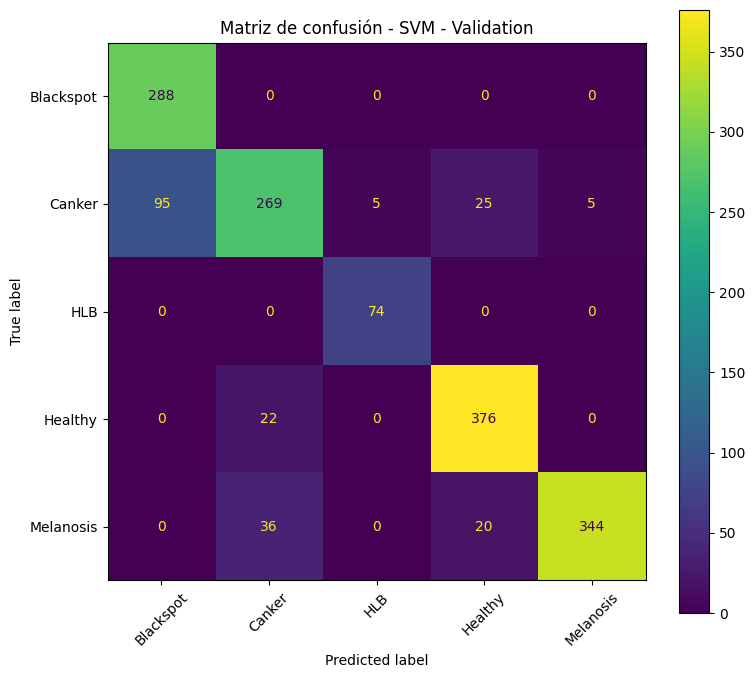

In [42]:
matriz_val_svm = confusion_matrix(
    y_val,
    pred_val_svm,
    labels=CLASES
)

figura, eje = plt.subplots(
    figsize=(8, 7)
)

visualizador = ConfusionMatrixDisplay(
    confusion_matrix=matriz_val_svm,
    display_labels=CLASES
)

visualizador.plot(
    ax=eje,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "Matriz de confusión - SVM - Validation"
)

plt.tight_layout()
plt.show()

In [43]:
RUTA_SVM_INICIAL = (
    RUTA_MODELOS
    / "svm_naranjas_inicial.joblib"
)

joblib.dump(
    {
        "modelo": pipeline_svm,
        "columnas_caracteristicas":
            COLUMNAS_CARACTERISTICAS,
        "clases": CLASES,
        "f1_validacion":
            macro_f1_val_svm
    },
    RUTA_SVM_INICIAL
)

print(
    "Modelo guardado en:",
    RUTA_SVM_INICIAL
)

Modelo guardado en: C:\MachinL\ProyectoFinal\modelos_ml\svm_naranjas_inicial.joblib


In [44]:
from itertools import product
from tqdm.auto import tqdm

VALORES_C = [
    0.1,
    1,
    10,
    100
]

VALORES_GAMMA = [
    "scale",
    0.001,
    0.01,
    0.1
]

resultados_svm = []

combinaciones = list(
    product(
        VALORES_C,
        VALORES_GAMMA
    )
)

for valor_c, valor_gamma in tqdm(
    combinaciones,
    desc="Ajustando SVM"
):
    modelo_temporal = Pipeline([
        (
            "escalador",
            StandardScaler()
        ),
        (
            "clasificador",
            SVC(
                kernel="rbf",
                C=valor_c,
                gamma=valor_gamma,
                class_weight="balanced",
                probability=False,
                random_state=42
            )
        )
    ])

    modelo_temporal.fit(
        X_train,
        y_train
    )

    predicciones = modelo_temporal.predict(
        X_val
    )

    accuracy = accuracy_score(
        y_val,
        predicciones
    )

    macro_f1 = f1_score(
        y_val,
        predicciones,
        average="macro",
        zero_division=0
    )

    resultados_svm.append({
        "C": valor_c,
        "gamma": valor_gamma,
        "accuracy_val": accuracy,
        "macro_f1_val": macro_f1
    })

Ajustando SVM:   0%|          | 0/16 [00:00<?, ?it/s]

In [45]:
df_resultados_svm = pd.DataFrame(
    resultados_svm
).sort_values(
    by="macro_f1_val",
    ascending=False
).reset_index(
    drop=True
)

display(
    df_resultados_svm
)

,C,gamma,accuracy_val,macro_f1_val
0,100.0,scale,0.890314,0.903514
1,100.0,0.01,0.888390,0.901960
2,100.0,0.001,0.878127,0.895700
3,10.0,scale,0.866581,0.880708
4,10.0,0.01,0.865298,0.879969
5,10.0,0.001,0.849262,0.870385
6,1.0,scale,0.840924,0.855220
7,1.0,0.01,0.838358,0.853034
8,1.0,0.001,0.819756,0.841970
9,0.1,scale,0.802437,0.808377


In [46]:
mejor_fila_svm = df_resultados_svm.iloc[0]

MEJOR_C = mejor_fila_svm["C"]
MEJOR_GAMMA = mejor_fila_svm["gamma"]

print("Mejor configuración SVM")
print("-----------------------")
print("C:", MEJOR_C)
print("Gamma:", MEJOR_GAMMA)
print(
    "Accuracy Validation:",
    f"{mejor_fila_svm['accuracy_val']:.4f}"
)
print(
    "Macro F1 Validation:",
    f"{mejor_fila_svm['macro_f1_val']:.4f}"
)

Mejor configuración SVM
-----------------------
C: 100.0
Gamma: scale
Accuracy Validation: 0.8903
Macro F1 Validation: 0.9035


In [47]:
RUTA_AJUSTE_SVM = (
    RUTA_RESULTADOS
    / "ajuste_parametros_svm.csv"
)

df_resultados_svm.to_csv(
    RUTA_AJUSTE_SVM,
    index=False,
    encoding="utf-8-sig"
)

print("Guardado en:", RUTA_AJUSTE_SVM)

Guardado en: C:\MachinL\ProyectoFinal\resultados_ml\ajuste_parametros_svm.csv


In [48]:
mejor_svm = Pipeline([
    (
        "escalador",
        StandardScaler()
    ),
    (
        "clasificador",
        SVC(
            kernel="rbf",
            C=MEJOR_C,
            gamma=MEJOR_GAMMA,
            class_weight="balanced",
            probability=True,
            random_state=42
        )
    )
])

mejor_svm.fit(
    X_train,
    y_train
)

pred_val_mejor_svm = mejor_svm.predict(
    X_val
)

print("Mejor SVM entrenado")

Mejor SVM entrenado


In [49]:
accuracy_mejor_svm = accuracy_score(
    y_val,
    pred_val_mejor_svm
)

macro_f1_mejor_svm = f1_score(
    y_val,
    pred_val_mejor_svm,
    average="macro",
    zero_division=0
)

print("MEJOR SVM EN VALIDATION")
print("-----------------------")
print(
    f"Accuracy: {accuracy_mejor_svm:.4f}"
)
print(
    f"Macro F1: {macro_f1_mejor_svm:.4f}"
)

print()

print(
    classification_report(
        y_val,
        pred_val_mejor_svm,
        labels=CLASES,
        target_names=CLASES,
        digits=4,
        zero_division=0
    )
)

MEJOR SVM EN VALIDATION
-----------------------
Accuracy: 0.8903
Macro F1: 0.9035

              precision    recall  f1-score   support

   Blackspot     0.8471    1.0000    0.9172       288
      Canker     0.8401    0.7769    0.8073       399
         HLB     0.9367    1.0000    0.9673        74
     Healthy     0.8836    0.9347    0.9084       398
   Melanosis     0.9829    0.8600    0.9173       400

    accuracy                         0.8903      1559
   macro avg     0.8981    0.9143    0.9035      1559
weighted avg     0.8937    0.8903    0.8892      1559



In [50]:
random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

pred_val_rf = random_forest.predict(
    X_val
)

print("Random Forest entrenado")

Random Forest entrenado


In [51]:
accuracy_val_rf = accuracy_score(
    y_val,
    pred_val_rf
)

macro_f1_val_rf = f1_score(
    y_val,
    pred_val_rf,
    average="macro",
    zero_division=0
)

weighted_f1_val_rf = f1_score(
    y_val,
    pred_val_rf,
    average="weighted",
    zero_division=0
)

print("RANDOM FOREST EN VALIDATION")
print("---------------------------")
print(
    f"Accuracy:    {accuracy_val_rf:.4f}"
)
print(
    f"Macro F1:    {macro_f1_val_rf:.4f}"
)
print(
    f"Weighted F1: {weighted_f1_val_rf:.4f}"
)

print()

print(
    classification_report(
        y_val,
        pred_val_rf,
        labels=CLASES,
        target_names=CLASES,
        digits=4,
        zero_division=0
    )
)

RANDOM FOREST EN VALIDATION
---------------------------
Accuracy:    0.8268
Macro F1:    0.8522
Weighted F1: 0.8257

              precision    recall  f1-score   support

   Blackspot     0.7404    1.0000    0.8508       288
      Canker     0.7151    0.6541    0.6832       399
         HLB     0.9610    1.0000    0.9801        74
     Healthy     0.8509    0.8744    0.8625       398
   Melanosis     0.9969    0.7950    0.8846       400

    accuracy                         0.8268      1559
   macro avg     0.8528    0.8647    0.8522      1559
weighted avg     0.8384    0.8268    0.8257      1559



In [52]:
comparacion_modelos = pd.DataFrame([
    {
        "modelo": "SVM",
        "accuracy_val": accuracy_mejor_svm,
        "macro_f1_val": macro_f1_mejor_svm
    },
    {
        "modelo": "Random Forest",
        "accuracy_val": accuracy_val_rf,
        "macro_f1_val": macro_f1_val_rf
    }
]).sort_values(
    by="macro_f1_val",
    ascending=False
).reset_index(
    drop=True
)

display(
    comparacion_modelos
)

,modelo,accuracy_val,macro_f1_val
0,SVM,0.890314,0.903514
1,Random Forest,0.826812,0.852241


In [53]:
RUTA_COMPARACION = (
    RUTA_RESULTADOS
    / "comparacion_modelos_validation.csv"
)

comparacion_modelos.to_csv(
    RUTA_COMPARACION,
    index=False,
    encoding="utf-8-sig"
)

In [54]:
joblib.dump(
    {
        "modelo": mejor_svm,
        "columnas_caracteristicas":
            COLUMNAS_CARACTERISTICAS,
        "clases": CLASES,
        "C": MEJOR_C,
        "gamma": MEJOR_GAMMA,
        "macro_f1_val":
            macro_f1_mejor_svm
    },
    RUTA_MODELOS / "svm_naranjas_mejor.joblib"
)

joblib.dump(
    {
        "modelo": random_forest,
        "columnas_caracteristicas":
            COLUMNAS_CARACTERISTICAS,
        "clases": CLASES,
        "macro_f1_val":
            macro_f1_val_rf
    },
    RUTA_MODELOS / "random_forest_naranjas.joblib"
)

print("Modelos guardados correctamente")

Modelos guardados correctamente


In [55]:
X_train_final = np.vstack([
    X_train,
    X_val
])

y_train_final = np.concatenate([
    y_train,
    y_val
])

print("Entrenamiento original:", X_train.shape)
print("Validation:", X_val.shape)
print("Entrenamiento final:", X_train_final.shape)
print("Test:", X_test.shape)

Entrenamiento original: (1846, 107)
Validation: (1559, 107)
Entrenamiento final: (3405, 107)
Test: (782, 107)


In [56]:
svm_final = Pipeline([
    (
        "escalador",
        StandardScaler()
    ),
    (
        "clasificador",
        SVC(
            kernel="rbf",
            C=float(MEJOR_C),
            gamma=MEJOR_GAMMA,
            class_weight="balanced",
            probability=True,
            random_state=42
        )
    )
])

svm_final.fit(
    X_train_final,
    y_train_final
)

print("SVM final entrenado correctamente")
print("C:", MEJOR_C)
print("Gamma:", MEJOR_GAMMA)

SVM final entrenado correctamente
C: 100.0
Gamma: scale


In [57]:
pred_test_svm = svm_final.predict(
    X_test
)

prob_test_svm = svm_final.predict_proba(
    X_test
)

accuracy_test_svm = accuracy_score(
    y_test,
    pred_test_svm
)

macro_f1_test_svm = f1_score(
    y_test,
    pred_test_svm,
    average="macro",
    zero_division=0
)

weighted_f1_test_svm = f1_score(
    y_test,
    pred_test_svm,
    average="weighted",
    zero_division=0
)

print("RESULTADOS FINALES DEL SVM EN TEST")
print("---------------------------------")
print(f"Accuracy:    {accuracy_test_svm:.4f}")
print(f"Macro F1:    {macro_f1_test_svm:.4f}")
print(f"Weighted F1: {weighted_f1_test_svm:.4f}")

RESULTADOS FINALES DEL SVM EN TEST
---------------------------------
Accuracy:    0.9578
Macro F1:    0.9666
Weighted F1: 0.9578


In [58]:
reporte_test_svm = classification_report(
    y_test,
    pred_test_svm,
    labels=CLASES,
    target_names=CLASES,
    digits=4,
    zero_division=0
)

print(reporte_test_svm)

              precision    recall  f1-score   support

   Blackspot     0.9931    0.9931    0.9931       145
      Canker     0.9350    0.9350    0.9350       200
         HLB     1.0000    1.0000    1.0000        37
     Healthy     0.9330    0.9750    0.9535       200
   Melanosis     0.9738    0.9300    0.9514       200

    accuracy                         0.9578       782
   macro avg     0.9670    0.9666    0.9666       782
weighted avg     0.9583    0.9578    0.9578       782



In [59]:
reporte_test_dict = classification_report(
    y_test,
    pred_test_svm,
    labels=CLASES,
    target_names=CLASES,
    output_dict=True,
    zero_division=0
)

df_reporte_test_svm = pd.DataFrame(
    reporte_test_dict
).transpose()

RUTA_REPORTE_TEST_SVM = (
    RUTA_RESULTADOS
    / "reporte_svm_test.csv"
)

df_reporte_test_svm.to_csv(
    RUTA_REPORTE_TEST_SVM,
    encoding="utf-8-sig"
)

print("Reporte guardado en:")
print(RUTA_REPORTE_TEST_SVM)

Reporte guardado en:
C:\MachinL\ProyectoFinal\resultados_ml\reporte_svm_test.csv


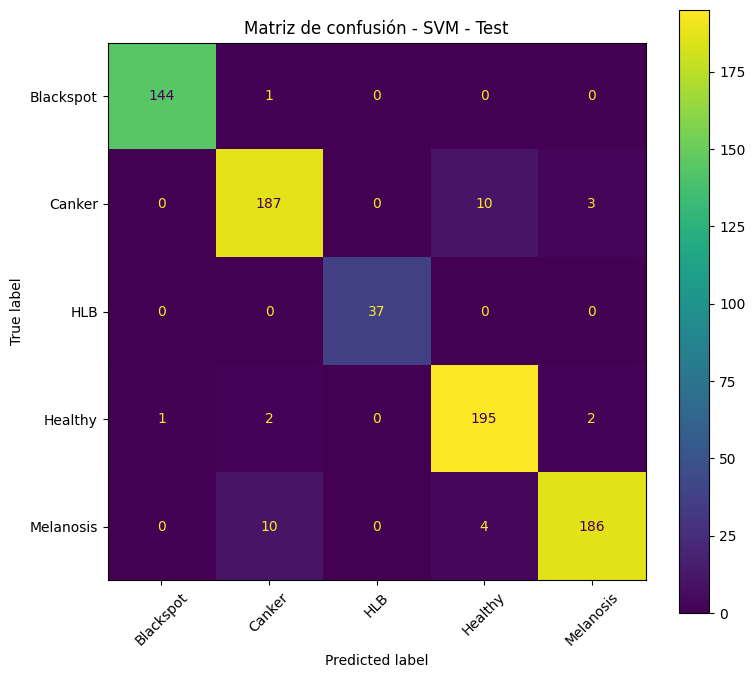

Matriz guardada en:
C:\MachinL\ProyectoFinal\resultados_ml\matriz_confusion_svm_test.png


In [60]:
matriz_test_svm = confusion_matrix(
    y_test,
    pred_test_svm,
    labels=CLASES
)

figura, eje = plt.subplots(
    figsize=(8, 7)
)

visualizador = ConfusionMatrixDisplay(
    confusion_matrix=matriz_test_svm,
    display_labels=CLASES
)

visualizador.plot(
    ax=eje,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "Matriz de confusión - SVM - Test"
)

plt.tight_layout()

RUTA_MATRIZ_SVM = (
    RUTA_RESULTADOS
    / "matriz_confusion_svm_test.png"
)

plt.savefig(
    RUTA_MATRIZ_SVM,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Matriz guardada en:")
print(RUTA_MATRIZ_SVM)

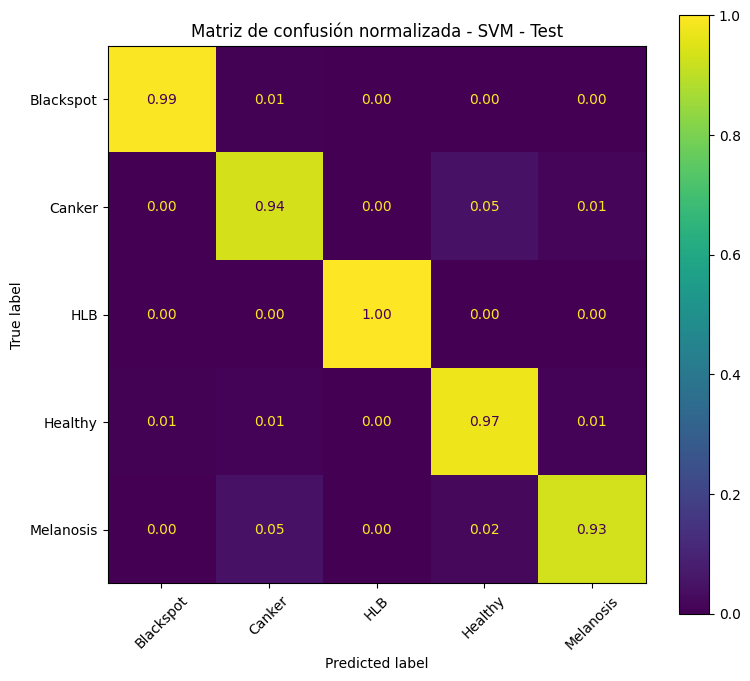

In [61]:
matriz_normalizada_svm = confusion_matrix(
    y_test,
    pred_test_svm,
    labels=CLASES,
    normalize="true"
)

figura, eje = plt.subplots(
    figsize=(8, 7)
)

visualizador = ConfusionMatrixDisplay(
    confusion_matrix=matriz_normalizada_svm,
    display_labels=CLASES
)

visualizador.plot(
    ax=eje,
    xticks_rotation=45,
    values_format=".2f"
)

plt.title(
    "Matriz de confusión normalizada - SVM - Test"
)

plt.tight_layout()
plt.show()

In [62]:
clases_svm = (
    svm_final
    .named_steps["clasificador"]
    .classes_
)

df_predicciones_svm = df_test[
    [
        "archivo",
        "ruta",
        "clase"
    ]
].copy()

df_predicciones_svm = (
    df_predicciones_svm.rename(
        columns={
            "clase": "clase_real"
        }
    )
)

df_predicciones_svm[
    "clase_predicha"
] = pred_test_svm

df_predicciones_svm[
    "confianza"
] = prob_test_svm.max(axis=1)

df_predicciones_svm[
    "correcto"
] = (
    df_predicciones_svm["clase_real"]
    ==
    df_predicciones_svm["clase_predicha"]
)

for indice, clase in enumerate(
    clases_svm
):
    df_predicciones_svm[
        f"probabilidad_{clase}"
    ] = prob_test_svm[:, indice]

RUTA_PREDICCIONES_SVM = (
    RUTA_RESULTADOS
    / "predicciones_svm_test.csv"
)

df_predicciones_svm.to_csv(
    RUTA_PREDICCIONES_SVM,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Aciertos:",
    df_predicciones_svm["correcto"].sum()
)

print(
    "Errores:",
    (~df_predicciones_svm["correcto"]).sum()
)

print("Predicciones guardadas en:")
print(RUTA_PREDICCIONES_SVM)

Aciertos: 749
Errores: 33
Predicciones guardadas en:
C:\MachinL\ProyectoFinal\resultados_ml\predicciones_svm_test.csv


In [63]:
RUTA_SVM_FINAL = (
    RUTA_MODELOS
    / "svm_naranjas_final.joblib"
)

joblib.dump(
    {
        "modelo": svm_final,
        "columnas_caracteristicas":
            COLUMNAS_CARACTERISTICAS,
        "clases": CLASES,
        "C": float(MEJOR_C),
        "gamma": MEJOR_GAMMA,
        "accuracy_test":
            accuracy_test_svm,
        "macro_f1_test":
            macro_f1_test_svm,
        "weighted_f1_test":
            weighted_f1_test_svm,
        "configuracion_extractor": {
            "fondo_gris": FONDO_GRIS,
            "umbral_fondo": UMBRAL_FONDO,
            "lbp_radio": LBP_RADIO,
            "lbp_puntos": LBP_PUNTOS,
            "lbp_metodo": LBP_METODO
        }
    },
    RUTA_SVM_FINAL
)

print("Modelo final guardado en:")
print(RUTA_SVM_FINAL)

Modelo final guardado en:
C:\MachinL\ProyectoFinal\modelos_ml\svm_naranjas_final.joblib


In [64]:
comparacion_final = pd.DataFrame([
    {
        "modelo": "MobileNetV3",
        "accuracy_test": 0.8734,
        "macro_f1_test": 0.8888,
        "weighted_f1_test": 0.8714
    },
    {
        "modelo": "SVM",
        "accuracy_test": accuracy_test_svm,
        "macro_f1_test": macro_f1_test_svm,
        "weighted_f1_test": weighted_f1_test_svm
    }
]).sort_values(
    by="macro_f1_test",
    ascending=False
).reset_index(
    drop=True
)

display(comparacion_final)

comparacion_final.to_csv(
    RUTA_RESULTADOS
    / "comparacion_final_ml_dl.csv",
    index=False,
    encoding="utf-8-sig"
)

,modelo,accuracy_test,macro_f1_test,weighted_f1_test
0,SVM,0.957801,0.966611,0.957788
1,MobileNetV3,0.873400,0.888800,0.871400
